In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Снимем зависимость температуры от ЭДС термопары

In [27]:
# EDS [мкВ]
# T   [C]
thermo_calib = pd.read_csv("thermopair.csv")


Приблизим разными много членами

In [28]:
def polynom(x, *args):
    return np.sum(
        [args[i] * np.power(x, i) for i in range(len(args))]
        , axis=0)

In [29]:
n_s = list(range(2, 5))

approximations = []

for n in n_s:
    x = thermo_calib["EDS"]
    y = thermo_calib["T"]

    popt, pcov = curve_fit(polynom, x, y, p0=tuple((1 for _ in range(n))))

    x_model = np.linspace(0, 5000, 10000)
    y_model = polynom(x_model, *popt)

    approximations.append(
        (n, x_model, y_model, popt, np.sqrt(np.diag(pcov)))
    )


[ 1.64719389e-01  2.55150331e-02 -5.08125035e-07]
[5.45825366e-02 5.37128352e-05 1.10511475e-08]
T = 0.16471938900395056 + 0.025515033084366978*EDS + -5.081250351590683e-07* EDS**2


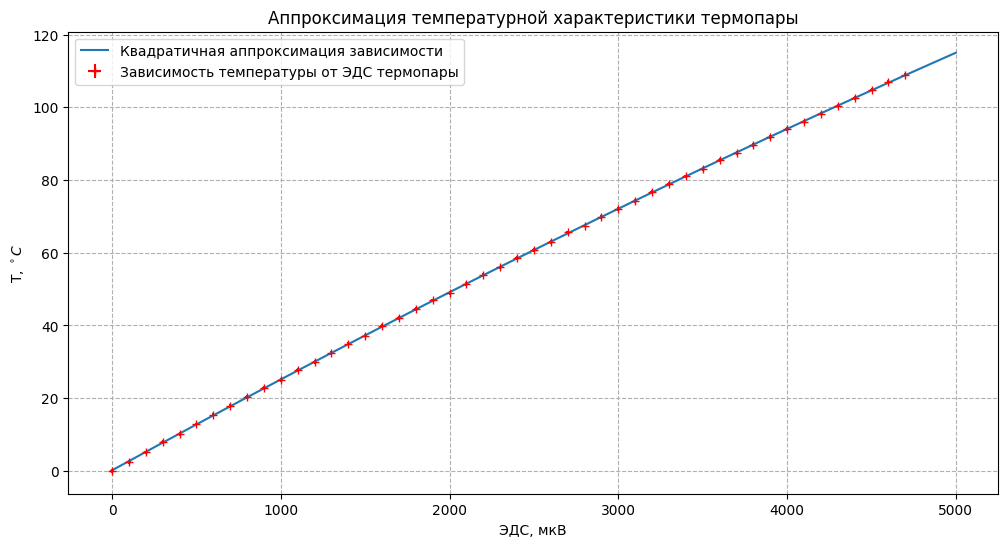

In [30]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")

plt.title(r"Аппроксимация температурной характеристики термопары")


plt.errorbar(x=thermo_calib["EDS"], xerr=10, y=thermo_calib["T"], yerr=0.5, fmt="+r", label=r"Зависимость температуры от ЭДС термопары")

for n, x_, y_, p, p_err in approximations:
    if n != 3:
        continue

    print(p)
    print(p_err)

    a_0, a_1, a_2 = p
    sigma_a_0, sigma_a_1, sigma_a_2 = p_err

    print(f"T = {a_0} + {a_1}*EDS + {a_2}* EDS**2")

    plt.plot(x_, y_, label=r"Квадратичная аппроксимация зависимости")

plt.xlabel(r"ЭДС, мкВ")
plt.ylabel(r"T, $^\circ C$")

plt.legend()

plt.savefig("pictures/thermopair_approximation.pdf")
plt.show()


Температура от ЭДС

$$ t(\varepsilon) = a_0 + a_1 \varepsilon + a_2 \varepsilon^2 $$

Погрешность

$$ \sigma_t = \sqrt{ \left( \cfrac{\partial t}{\partial a_0} \right)^2 \sigma_{a_0}^2 + \left( \cfrac{\partial t}{\partial a_1} \right)^2 \sigma_{a_1}^2 + \left( \cfrac{\partial t}{\partial a_2} \right)^2 \sigma_{a_2}^2 + \left(\cfrac{\partial t}{\partial \varepsilon} \right)^2 \sigma_\varepsilon^2 } = \sqrt{ \sigma_{a_0}^2 + \varepsilon^2 \sigma_{a_1}^2 + \varepsilon^4 \sigma_{a_2}^2 + \left(a_1 + 2 \varepsilon a_2 \right)^2 \sigma_\varepsilon^2 } $$

In [31]:
print(f"a = {a_0:.2f} +- {sigma_a_0:.2f}")
print(f"b = {a_1:.4f} +- {sigma_a_1:.4f}")
print(f"c = {a_2:.8f} +- {sigma_a_2:.8f}")

a = 0.16 +- 0.05
b = 0.0255 +- 0.0001
c = -0.00000051 +- 0.00000001


In [32]:
def t_from_eds(eds):
    return a_0 + a_1*eds + a_2* eds**2

def sigma_t_from_eds(eds, sigma_eds):
    return np.sqrt(
        np.square(sigma_a_0) + 
        np.square(eds * sigma_a_1) + 
        np.square(eds**2 * sigma_a_2) + 
        np.square(a_1 + 2 * eds * a_2) * np.square(sigma_eds)
    )

Измеряем частоты от температуры

In [33]:
# V [mV]
# f [kHz]
# f_0 [kHz]
data = pd.read_csv("data.csv")

In [34]:
# нуль термопары
V_0 = np.float128('0.11') # mV

# коэффициент наклона термопары (приближенный)
k_approx = np.float128('41')        # mkV/C
sigma_K_approx = np.float128('0.5') # mkV/C

# Погрешность V
sigma_V = np.float128('0.01') # mV

# Погрешность f, f_0
sigma_f = np.float128('0.05') # kHz

# перевод в кельвины
T_0 = np.float128("273.15") # K


# комнатная температура
t_0 = np.float128('26') # C

In [35]:
data["V_true"] = data["V"] - V_0

In [36]:
# кажется была перепутана полярность
data["t_approx"] = - 1000* data["V_true"] / k_approx + t_0
data["T_approx"] = data["t_approx"] + T_0


Погрешность температуры

$$ \sigma_T = \sigma_t = t \cdot \sqrt{\left(\cfrac{\sigma_V}{V}\right)^2 + \left(\cfrac{\sigma_k}{k}\right)^2} $$

In [37]:
data["sigma_T_approx"] = np.abs((data["t_approx"] - t_0) * np.sqrt(
    np.square(sigma_V / data["V_true"]) + 
    np.square(sigma_K_approx/ k_approx)
))

Точные вычисления

In [38]:
data["t"] = t_from_eds(-1000 * data["V_true"]) + t_0
data["sigma_t"] = sigma_t_from_eds(-1000 * data["V_true"], 1000 * sigma_V)

data["T"] = data["t"] + T_0
data["sigma_T"] = data["sigma_t"]

график частот от температуры


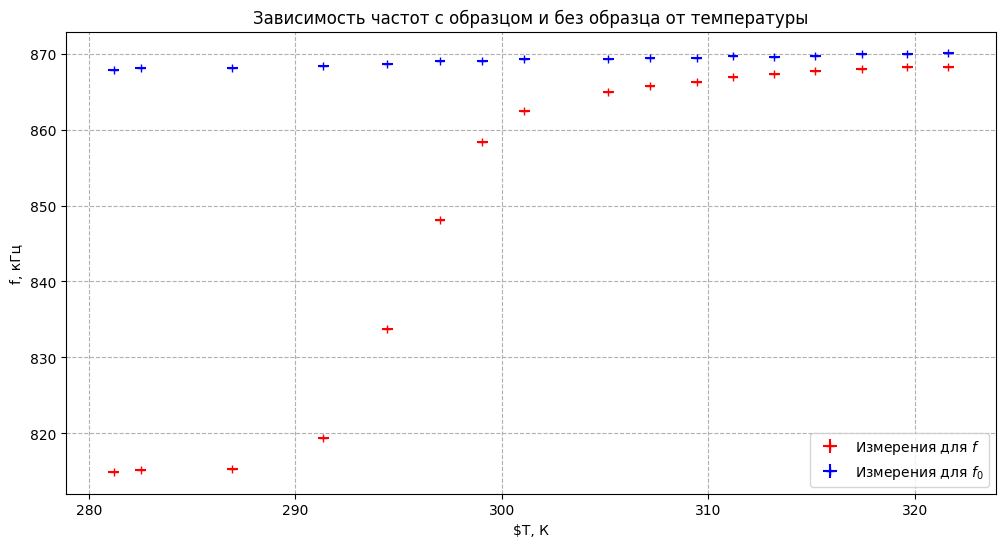

In [39]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")
plt.title(r"Зависимость частот с образцом и без образца от температуры")


plt.errorbar(x=data["T"], xerr=data["sigma_T"], y=data["f"], yerr=sigma_f, fmt="+r", label=r"Измерения для $f$")
plt.errorbar(x=data["T"], xerr=data["sigma_T"], y=data["f_0"], yerr=sigma_f, fmt="+b", label=r"Измерения для $f_0$")

plt.xlabel(r"$T, К")
plt.ylabel(r"f, кГц")

plt.legend()
plt.savefig("pictures/frequencies_temperature.pdf")
plt.show()


считаем величину

$$ K = \cfrac{f^2}{f_0^2 - f^2} $$

Ее погрешность

$$ \sigma_K = \sqrt{\left( \cfrac{\partial K}{\partial f} \right)^2\sigma_f^2 + \left( \cfrac{\partial K}{\partial f_0} \right)^2\sigma_{f_0}^2} $$

частные производные

$$ \cfrac{\partial K}{\partial f} = \cfrac{2f}{f_0^2 - f^2} + f^2 \left( - \cfrac{1}{\left( f^2 - f_0^2 \right)^2} \cdot 2f \right) = \cfrac{2f}{\left( f^2 - f_0^2 \right)^2} \left( f^2 - f_0^2 - f^2 \right) = -f_0 \cfrac{2f f_0}{\left( f^2 - f_0^2 \right)^2} $$


$$ \cfrac{\partial K}{\partial f_0} = - \cfrac{f^2}{\left( f^2 - f_0^2 \right)^2} \cdot \left(-2f_0\right) = f \cfrac{2f f_0}{\left( f^2 - f_0^2 \right)^2} $$

$$ \sigma_K = \sigma_f \cfrac{2 f f_0}{\left( f^2 - f_0^2 \right)^2} \sqrt{f^2 + f_0^2} $$

In [40]:
data["K"] = data["f"]**2 / (data["f_0"]**2 - data["f"]**2)

data["sigma_K"] = sigma_f * 2 * data["f"] * data["f_0"] * np.sqrt(data["f"]**2 + data["f_0"]**2) / np.square(data["f"]**2 - data["f_0"]**2)

Разделение на прямую и не прямую по критерию $T > 295$

In [41]:
data_linear = pd.DataFrame(columns=data.columns)
data_nonlinear = pd.DataFrame(columns=data.columns)

data_ejects = pd.DataFrame(columns=data.columns)
ejects = set([16, 14])

for i in range(len(data["T"])):
    if i in ejects:
        data_ejects.loc[len(data_ejects)] = data.loc[i]
        continue

    if data["T"].iloc[i] > 297:
        data_linear.loc[len(data_linear)] = data.loc[i]
    else:
        data_nonlinear.loc[len(data_nonlinear)] = data.loc[i]

Приблизим прямую часть

In [42]:
def mnk(x, y, sigma_x, sigma_y, need_b=True, no_sigma=False):
    if len(x) != len(y):
        return

    n = len(x)
    x = np.array(x)
    y = np.array(y)
    sigma_x = np.array(sigma_x)
    sigma_y = np.array(sigma_y)

    my = np.mean(y)
    mx = np.mean(x)
    mx2 = np.mean(x ** 2)
    my2 = np.mean(y ** 2)
    mxy = np.mean(y * x)

    if need_b:
        # y = kx + b
        k = (mxy - my * mx) / (mx2 - mx ** 2)
        # print(f"k = ({mxy} - {my} * {mx}) / ({mx2} - {mx}**2) = {k}")
        b = my - k * mx

        sigma_k = (1 / n ** 0.5) * ((my2 - my ** 2) / (mx2 - mx ** 2) - k ** 2) ** 0.5
        sigma_b = sigma_k * (mx2 - mx * mx) ** 0.5
        if not no_sigma:
            return x, y, sigma_x, sigma_y, k, sigma_k, b, sigma_b
        else:
            return x, y, k, sigma_k, b, sigma_b
    else:
        # y = kx
        k = mxy / mx2

        sigma_k = (1 / n ** 0.5) * (my2 / mx2 - k ** 2) ** 0.5
        if not no_sigma:
            return x, y, sigma_x, sigma_y, k, sigma_k
        else:
            return x, y, k, sigma_k

In [43]:
_, _, _, _, k, sigma_k, b, sigma_b = mnk(
    x=data_linear["T"], sigma_x=data_linear["sigma_T"], y=data_linear["K"], sigma_y=data_linear["sigma_K"], need_b=True, no_sigma=False
    )

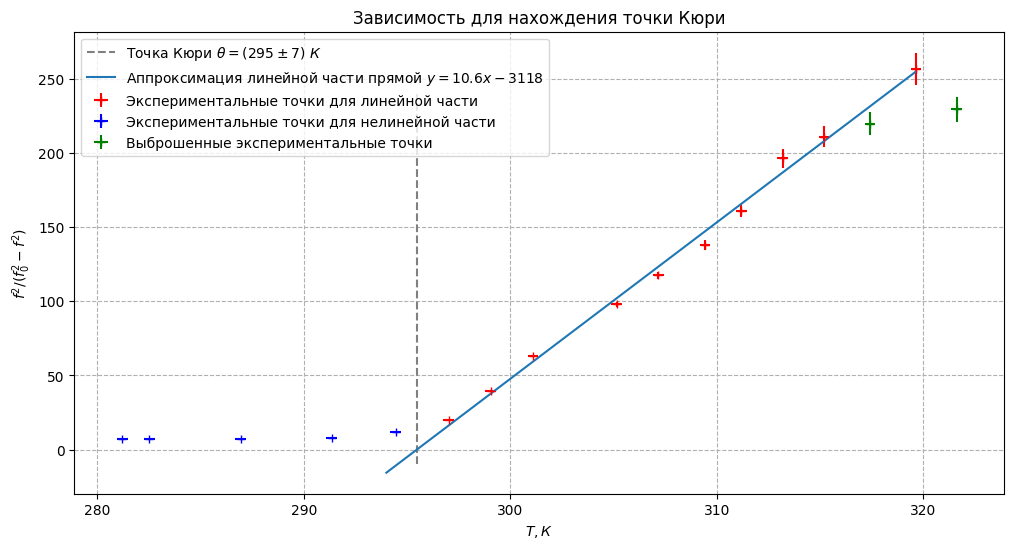

In [44]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")
plt.title(r"Зависимость для нахождения точки Кюри")


plt.errorbar(x=data_linear["T"], xerr=data_linear["sigma_T"], y=data_linear["K"], yerr=data_linear["sigma_K"], 
             fmt="+r", label="Экспериментальные точки для линейной части")
plt.errorbar(x=data_nonlinear["T"], xerr=data_nonlinear["sigma_T"], y=data_nonlinear["K"], yerr=data_nonlinear["sigma_K"], 
             fmt="+b", label="Экспериментальные точки для нелинейной части")

plt.errorbar(x=data_ejects["T"], xerr=data_ejects["sigma_T"], y=data_ejects["K"], yerr=data_ejects["sigma_K"], 
             fmt="+g", label="Выброшенные экспериментальные точки")

x_model = np.linspace(294, max(data_linear["T"]))
y_model = k* x_model + b


theta = - b / k

sigma_theta = theta * np.sqrt(
    np.square(sigma_b / b) +
    np.square(sigma_k / k)
)

plt.vlines(theta, ymin=-10, ymax=240, linestyles="--", colors="grey", label=fr"Точка Кюри $\theta = ({theta:.0f} \pm {sigma_theta:.0f}) ~ К$")


plt.plot(x_model, y_model, label=rf"Аппроксимация линейной части прямой $y = {k:.1f} x {b:.0f}$")

plt.xlabel(r"$T, К$")
plt.ylabel(r"$f^2 / (f_0^2 - f^2)$")

plt.legend()
plt.savefig("pictures/kyuri.pdf")
plt.show()


Вычисление обменного интеграла

$$ J = \dfrac{3k_\text{Б}\Theta}{2nS(S+1)} $$

In [45]:
# Постоянная больцмана [1e-23 * Дж/К]
k_B = np.float128('1.380649')

# параметры для гадолиния
n = 12
S = 7 / 2

# для перевода в эВ, [1e-19]
q_e = np.float128('1.6')

In [46]:
# Дж
J = 3 * k_B * theta / 2 / n / S / (S + 1)
sigma_J = J * sigma_theta / theta

# К
J_K = 3 * theta / 2 / n / S / (S + 1)
sigma_J_K = J_K * sigma_theta / theta

# мэВ
J_eV = 1e6 * 1e-4 * 3 * k_B * theta / 2 / n / S / (S + 1) / q_e 
sigma_J_eV = J_eV * sigma_theta / theta



print(f"J = ({J:.2f} +- {sigma_J:.2f}) * 1e-23 Дж")
print(f"J = ({J_K:.2f} +- {sigma_J_K:.2f}) К")
print(f"J = ({J_eV:.0f} +- {sigma_J_eV:.0f}) мкэВ")


J = (3.24 +- 0.08) * 1e-23 Дж
J = (2.35 +- 0.05) К
J = (202 +- 5) мкэВ


Посчитаем магнитную чувствительность

$$ \varkappa = \cfrac{1}{4 \pi} \cfrac{f_0^2 - f^2}{f^2} = \cfrac{1}{4 \pi K} $$

$$ \sigma_\varkappa = \left| \cfrac{\partial \varkappa}{\partial K} \right| \sigma_K = \left| - \cfrac{1}{4 \pi K^2} \right| \sigma_K = \cfrac{\sigma_K}{4 \pi K^2} = \varkappa \cfrac{\sigma_k}{K} $$

In [47]:
data["kappa"] = 1 / 4 / np.pi / data["K"]
data["sigma_kappa"] = data["kappa"] * data["sigma_K"] / data["K"]

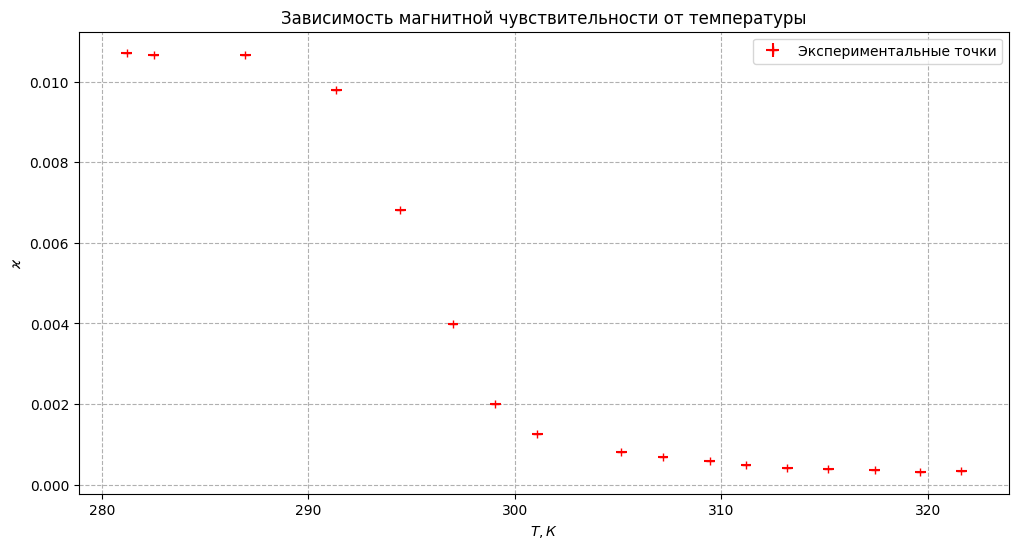

In [48]:
plt.figure(figsize=(12, 6))
plt.grid(True, linestyle="--")
plt.title(r"Зависимость магнитной чувствительности от температуры")


plt.errorbar(x=data["T"], xerr=data["sigma_T"], y=data["kappa"], yerr=data["sigma_kappa"], 
             fmt="+r", label="Экспериментальные точки")


plt.xlabel(r"$T, К$")
plt.ylabel(r"$\varkappa$")

plt.legend()
plt.savefig("pictures/kappa_graph.pdf")
plt.show()


Проверка через $\chi^2$

$$ \chi^2 = \sum \frac{\left( y - \hat{y} \right)^2}{\sigma_y^2 + \sigma_{\hat{y}}^2} $$

In [49]:
def chi2(y_true, y_pred, sigma):
    return np.sum(
        np.square(y_pred - y_true) / np.square(sigma)
    )

$$\hat{y} = kx + b, \ \ \ \sigma_{\hat{y}} = \sqrt{ \left( \cfrac{\partial \hat{y}}{\partial x} \right)^2 \sigma_x^2 + \left( \cfrac{\partial \hat{y}}{\partial k} \right)^2 \sigma_k^2 + \left( \cfrac{\partial \hat{y}}{\partial b} \right)^2 \sigma_b^2 } = \sqrt{ k^2 \sigma_x^2 + x^2 \sigma_k^2 + \sigma_b^2 } $$

In [50]:
x = data_linear["T"]
sigma_x = data_linear["sigma_T"]
y = data_linear["K"]
sigma_y = data_linear["sigma_K"]

sigma_y_hat = np.sqrt(
    np.square(k * sigma_x) + np.square(x * sigma_k) + np.square(sigma_b)
)

sigma_chi2 = np.sqrt(
    sigma_y_hat**2 + sigma_y**2
)

y_pred = k*x + b

# for i in range(len(y_pred)):
#     print(sigma_y[i], sigma_y_hat[i], np.square(y[i] - y_pred[i]), sigma_chi2[i]**2, np.square(y[i] - y_pred[i]) / sigma_chi2[i]**2**2)

print(f"chi2 = {chi2(y, y_pred, sigma_chi2):.3f}")

chi2 = 0.050
